# 07 — Final Comparison & Discussion

**Goal:** pull together every result from Notebooks 02, 04, 05, and 06 into one place.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

classical = pd.read_csv("../results/classical_ml_metrics.csv")
nn = pd.read_csv("../results/nn_metrics.csv")
cnn = pd.read_csv("../results/cnn_metrics.csv")
transfer = pd.read_csv("../results/transfer_learning_comparison.csv")

print(classical.shape, nn.shape, cnn.shape, transfer.shape)

(6, 11) (3, 10) (3, 6) (3, 2)


## 1. Tabular data: classical ML vs. neural network, all in one chart

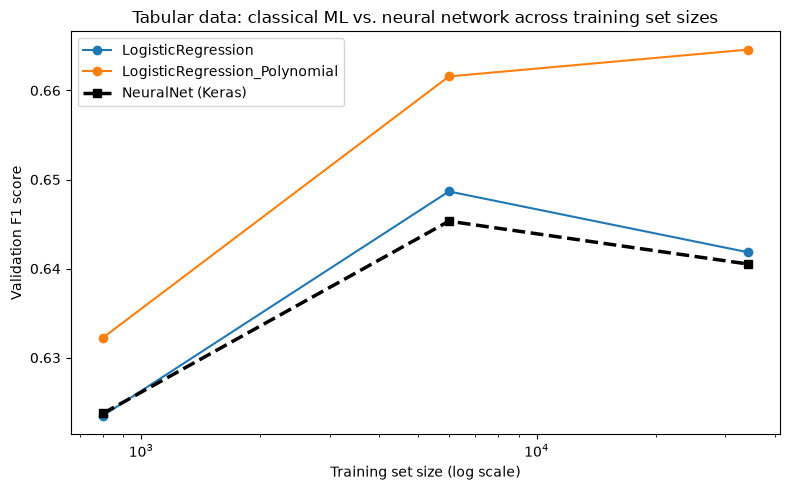

In [2]:
plt.figure(figsize=(8,5))
for model_name in classical["model"].unique():
    sub = classical[classical["model"] == model_name].sort_values("n_train")
    plt.plot(sub["n_train"], sub["val_f1"], marker="o", label=model_name)

nn_sorted = nn.sort_values("n_train")
plt.plot(nn_sorted["n_train"], nn_sorted["val_f1"], marker="s", linewidth=2.5,
          linestyle="--", color="black", label="NeuralNet (Keras)")

plt.xscale("log")
plt.xlabel("Training set size (log scale)")
plt.ylabel("Validation F1 score")
plt.title("Tabular data: classical ML vs. neural network across training set sizes")
plt.legend()
plt.tight_layout()
plt.savefig("../results/figures/FINAL_tabular_comparison.png", dpi=150)
plt.show()

## 2. Training time comparison

Performance isn't the only axis worth comparing — compute cost matters a lot in practice.

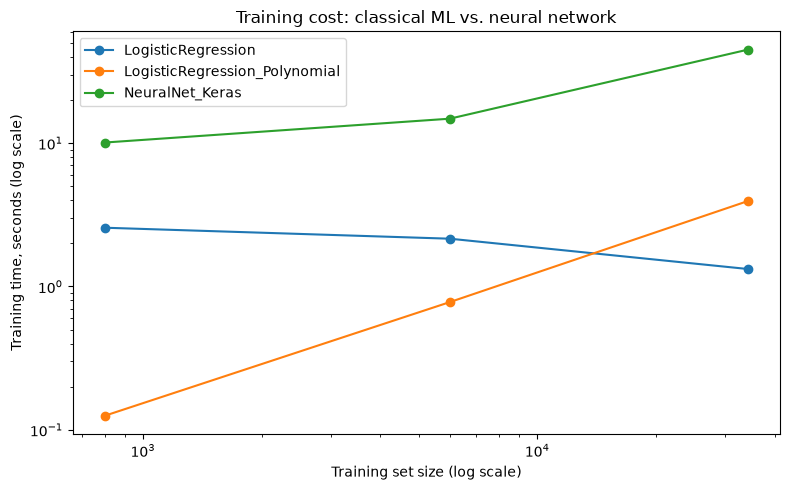

In [3]:
time_compare = pd.concat([
    classical[["model", "dataset_size_name", "n_train", "train_time_sec"]],
    nn.rename(columns={"model":"model"})[["model", "dataset_size_name", "n_train", "train_time_sec"]],
])

plt.figure(figsize=(8,5))
for model_name in time_compare["model"].unique():
    sub = time_compare[time_compare["model"] == model_name].sort_values("n_train")
    plt.plot(sub["n_train"], sub["train_time_sec"], marker="o", label=model_name)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size (log scale)")
plt.ylabel("Training time, seconds (log scale)")
plt.title("Training cost: classical ML vs. neural network")
plt.legend()
plt.tight_layout()
plt.savefig("../results/figures/FINAL_training_time_comparison.png", dpi=150)
plt.show()

## 3. Image data: CNN from scratch across sizes, and transfer learning at the small-data end

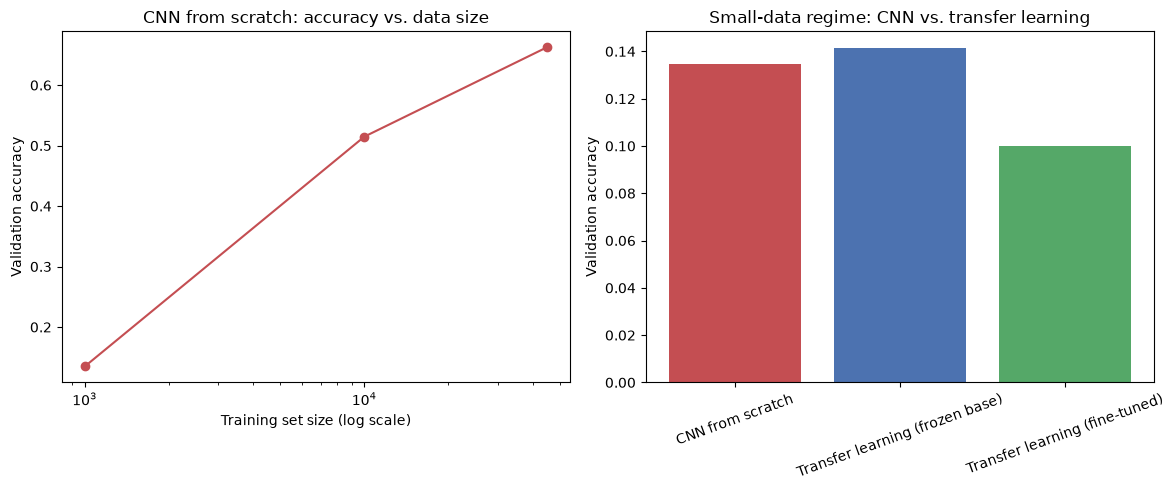

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

cnn_sorted = cnn.sort_values("n_train")
axes[0].plot(cnn_sorted["n_train"], cnn_sorted["val_accuracy"], marker="o", color="#C44E52")
axes[0].set_xscale("log")
axes[0].set_xlabel("Training set size (log scale)")
axes[0].set_ylabel("Validation accuracy")
axes[0].set_title("CNN from scratch: accuracy vs. data size")

axes[1].bar(transfer["approach"], transfer["val_accuracy"], color=["#C44E52", "#4C72B0", "#55A868"])
axes[1].set_ylabel("Validation accuracy")
axes[1].set_title("Small-data regime: CNN vs. transfer learning")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("../results/figures/FINAL_image_results.png", dpi=150)
plt.show()

## 4. Master results table

One table with every experiment run in the whole project.

In [5]:
classical_view = classical[["model","dataset_size_name","n_train","val_accuracy","val_f1","val_roc_auc","train_time_sec"]]
nn_view = nn.rename(columns={"model":"model"})[["model","dataset_size_name","n_train","val_accuracy","val_f1","val_roc_auc","train_time_sec"]]
master = pd.concat([classical_view, nn_view], ignore_index=True)
master.to_csv("../results/MASTER_results_table.csv", index=False)
master.sort_values(["dataset_size_name", "val_f1"], ascending=[True, False])

,model,dataset_size_name,n_train,val_accuracy,val_f1,val_roc_auc,train_time_sec
5,LogisticRegression_Polynomial,large,34187,0.853439,0.664585,0.910796,3.943300
2,LogisticRegression,large,34187,0.845115,0.641843,0.904838,1.324182
8,NeuralNet_Keras,large,34187,0.848663,0.640519,0.907307,44.883202
4,LogisticRegression_Polynomial,medium,6000,0.848799,0.661576,0.907065,0.778418
1,LogisticRegression,medium,6000,0.845524,0.648665,0.902990,2.154509
7,NeuralNet_Keras,medium,6000,0.848799,0.645327,0.903583,14.807698
3,LogisticRegression_Polynomial,small,800,0.839656,0.632238,0.888121,0.125446
6,NeuralNet_Keras,small,800,0.837336,0.623737,0.885408,10.095713
0,LogisticRegression,small,800,0.838974,0.623484,0.891655,2.570165


## Summary

This notebook aggregated every experiment in the project into the headline comparison charts and a
master results table.